In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vivmankar/asian-vs-african-elephant-image-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 51.8M/51.8M [00:00<00:00, 105MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1):
['dataset']


In [ ]:
import os

# Update path to match the 'dataset' directory in the elephant dataset
data_path = os.path.join(path, 'dataset')

# List subdirectories (usually 'train' and 'test' classes)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['test', 'train']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1/dataset) ---
Found 1028 images. Displaying 6 sample images:


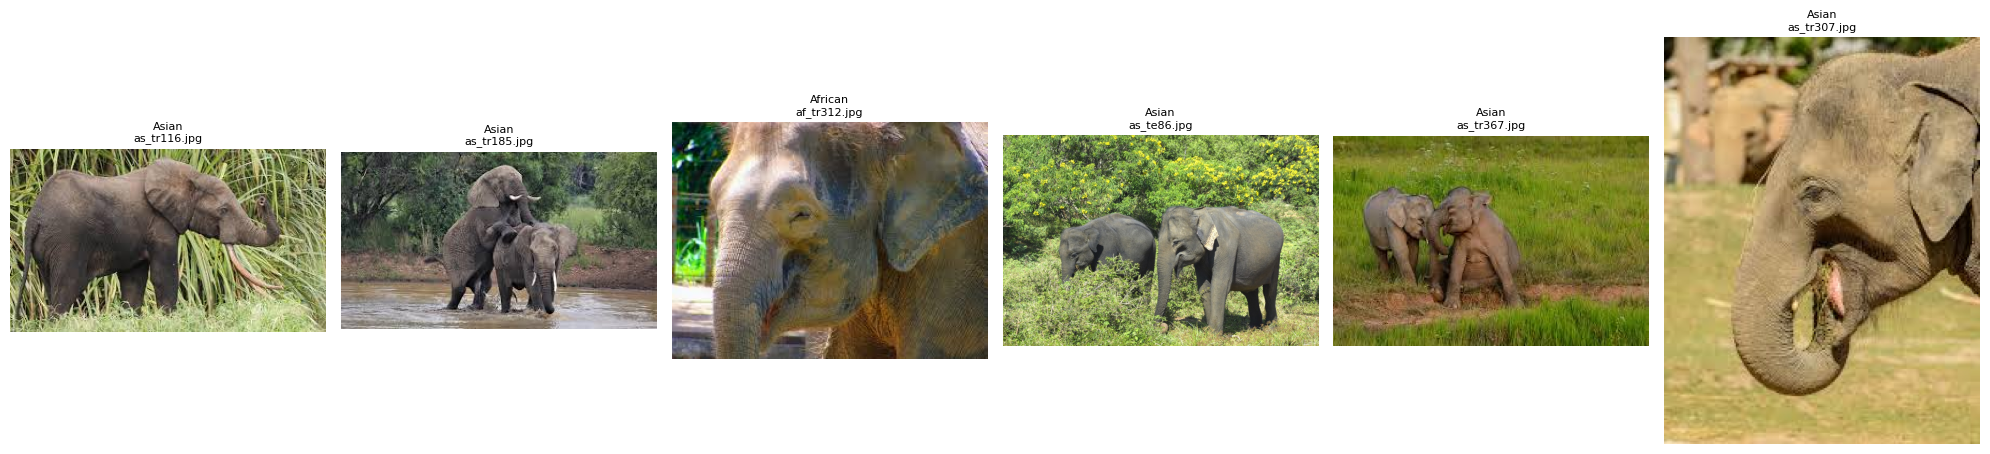

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent folder) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct 'dataset' path
data_path = os.path.join(path, 'dataset')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import time
import copy

# 1. Check GPU Availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [ ]:
# 2. Data Preparation and ResNet Model Construction
# Transforms for ResNet (requires 224x224)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Loading datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_path, x), data_transforms[x]) for x in ['train', 'test']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

# Initialize ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model loaded onto {device}. Classes: {class_names}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]

Model loaded onto cpu. Classes: ['African', 'Asian']


In [ ]:
# 3. Training Loop
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
num_epochs = 10

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')

    for phase in ['train', 'test']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Epoch 1/10
train Loss: 0.9333 Acc: 0.5333
test Loss: 0.9855 Acc: 0.5266
Epoch 2/10
train Loss: 0.7078 Acc: 0.5595
test Loss: 0.6880 Acc: 0.6011
Epoch 3/10
train Loss: 0.6671 Acc: 0.6071
test Loss: 0.7230 Acc: 0.6117
Epoch 4/10
train Loss: 0.6599 Acc: 0.6155
test Loss: 0.6046 Acc: 0.6809
Epoch 5/10
train Loss: 0.6371 Acc: 0.6476
test Loss: 0.5890 Acc: 0.6702
Epoch 6/10
train Loss: 0.6554 Acc: 0.6155
test Loss: 0.6575 Acc: 0.6649
Epoch 7/10
train Loss: 0.6311 Acc: 0.6500
test Loss: 0.5895 Acc: 0.7181
Epoch 8/10
train Loss: 0.6708 Acc: 0.6048
test Loss: 0.5694 Acc: 0.7287
Epoch 9/10
train Loss: 0.6437 Acc: 0.6333
test Loss: 0.5619 Acc: 0.7181
Epoch 10/10
train Loss: 0.6172 Acc: 0.6631
test Loss: 0.4758 Acc: 0.7766



--- Training Summary ---
Final Train Accuracy: 0.6631
Final Test Accuracy: 0.7766


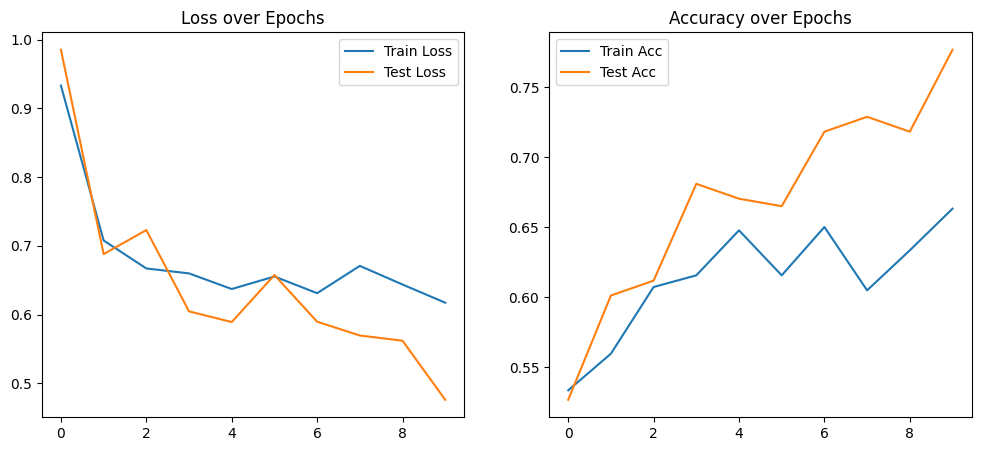

In [ ]:
# 4. Results Summary and Visualization
print("\n--- Training Summary ---")
print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()